# Context OverFlow Problem Solution2 (Summerization)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from dotenv import load_dotenv
import os

from langchain_openai import ChatOpenAI

from langchain_groq import ChatGroq

from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    AIMessage,
    SystemMessage,
    RemoveMessage,
)

from langgraph.graph import (
    StateGraph,
    START,
    END,
)

from langgraph.graph.message import add_messages
from langgraph.checkpoint.sqlite import SqliteSaver

import sqlite3


In [23]:
# ==========================================
# ENV
# ==========================================

load_dotenv()

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)


summerization_llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)


In [24]:
# ==========================================
# STATE
# ==========================================

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    summary: str



In [26]:
# ==========================================
# CHAT NODE
# ==========================================

def chatbot(state: ChatState):

    summary = state.get("summary", "")

    messages = []

    if summary:
        messages.append(
            SystemMessage(
                content=f"""
Conversation Summary:

{summary}

Use this summary as memory while answering.
"""
            )
        )

    messages.extend(state["messages"])

    response = llm.invoke(messages)

    return {
        "messages": [response]
    }


In [27]:
# ==========================================
# SUMMARIZE NODE
# ==========================================

def summarize_node(state: ChatState):

    old_summary = state.get("summary", "")

    if old_summary:

        prompt = f"""
Current Summary:

{old_summary}

Extend this summary using the new conversation.

Keep:

- User information
- Preferences
- Important facts
- Previous discussions
- Long-term memory
"""

    else:

        prompt = """
Create a concise summary of this conversation.

Keep:

- User information
- Preferences
- Important facts
"""

    print()
    print(state['messages'])
    print()
    print("That was before calling llm")
    response = summerization_llm.invoke(

        [HumanMessage(content=prompt)] +

        state["messages"]

    )

    print("SUMMARY CREATED")
    print(response.content)

    delete_messages = [

        RemoveMessage(id=m.id)

        for m in state["messages"][:-2]

    ]

    return {

        "summary": response.content,

        "messages": delete_messages

    }


In [19]:
# ==========================================
# ROUTER
# ==========================================

def should_summarize(state: ChatState):

    if len(state["messages"]) >= 10:
        return "summarize"

    return END

In [28]:
# ==========================================
# GRAPH
# ==========================================

conn = sqlite3.connect(database='summerization_stm3.db', check_same_thread=False)

checkpointer = SqliteSaver(conn=conn)



builder = StateGraph(ChatState)

builder.add_node("chat", chatbot)

builder.add_node("summarize", summarize_node)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        # Function Return Value : Target Node
        "summarize": "summarize",
        END: END
    }
)

builder.add_edge(
    "summarize",
    END
)

graph = builder.compile(
    checkpointer=checkpointer
)


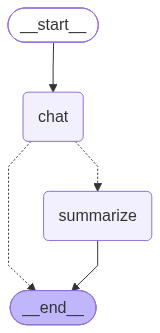

In [11]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
# ==========================================
# CONFIG
# ==========================================

config = {

    "configurable": {

        "thread_id": "thread_1"

    }

}

In [29]:
# ==========================================
# CLI LOOP
# ==========================================

print("=" * 60)
print(" LangGraph Summarization Memory Chatbot ")
print("Type 'exit' to quit.")
print("=" * 60)

while True:

    user = input("\nYou : ")

    if user.lower() == "exit":
        break

    result = graph.invoke(

        {

            "messages": [

                HumanMessage(content=user)

            ]

        },

        config=config

    )

    print("\nAI :", result["messages"][-1].content)

    state = graph.get_state(config)

    print("DEBUG:", repr(state.values))

    print("\n----------------------------")
    print("Stored Messages :", len(state.values["messages"]))

    # print(state)    
    summary = state.values.get("summary")   

    if summary:

        print("\nCurrent Summary\n")

        print(summary)

    else:

        print("\nNo Summary Yet")

    print("----------------------------")

 LangGraph Summarization Memory Chatbot 
Type 'exit' to quit.

[HumanMessage(content="now i'm learning LLM", additional_kwargs={}, response_metadata={}, id='e79a4b86-171d-4b61-9765-e28c6d398b08'), AIMessage(content="You're learning about Large Language Models (LLMs). That's a fascinating topic. LLMs are a type of artificial intelligence (AI) designed to process and understand human language. They can be used for a wide range of applications, such as language translation, text summarization, and conversation generation (like our chat right now).\n\nWhat specifically are you learning about LLMs? Are you interested in the technical aspects, such as how they're trained and implemented, or more about their practical applications and uses?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 104, 'prompt_tokens': 239, 'total_tokens': 343, 'completion_time': 0.332417584, 'completion_tokens_details': None, 'prompt_time': 0.053185844, 'prompt_tokens_details': None, 'q